Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `loggin

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.194981,0.256611,0.911697,0.911699
2,0.117115,0.286198,0.908257,0.908125
3,0.082755,0.339804,0.916284,0.916273


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


--- Evaluation Results ---


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.082755,0.256217,3,0.911697,0.911699


{'eval_loss': 0.25621676445007324, 'eval_accuracy': 0.911697247706422, 'eval_f1': 0.911698990159362}


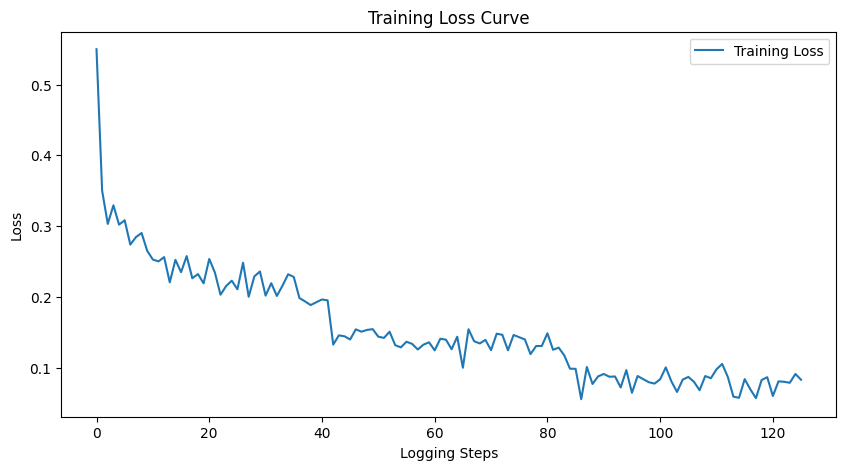


--- Example Predictions ---


Text: it 's a charming and often affecting journey . 
True: 1 ('Positive')
Pred: 1 ('Positive')
------------------------------
Text: unflinchingly bleak and desperate 
True: 0 ('Negative')
Pred: 0 ('Negative')
------------------------------
Text: allows us to hope that nolan is poised to embark a major career as a commercial yet inventive filmmaker . 
True: 1 ('Positive')
Pred: 1 ('Positive')
------------------------------
Text: the acting , costumes , music , cinematography and sound are all astounding given the production 's austere locales . 
True: 1 ('Positive')
Pred: 1 ('Positive')
------------------------------
Text: it 's slow -- very , very slow . 
True: 0 ('Negative')
Pred: 0 ('Negative')
------------------------------


In [2]:
!pip install -U transformers datasets accelerate scikit-learn matplotlib

import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

# 1. Load Tokenizer and Model (BERT-base-uncased)
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 2. Load Dataset
dataset = load_dataset("sst2")

# 3. Tokenization function
def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Tokenize the entire dataset
tokenized_dataset = dataset.map(tokenize, batched=True)
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 4. Metrics calculation function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

# 5. Training Arguments (As per task requirements)
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",            # <--- Ուղղված է (նախկին evaluation_strategy-ի փոխարեն)
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
)

# 6. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

# 7. Train the model
trainer.train()

# 8. Evaluation
print("\n--- Evaluation Results ---")
results = trainer.evaluate()
print(results)

# 9. Plotting Training & Validation Loss
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Training Loss")
plt.xlabel("Logging Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

# 10. Example Predictions (5 examples)
print("\n--- Example Predictions ---")
val_subset = tokenized_dataset["validation"].select(range(5))
predictions = trainer.predict(val_subset)
preds = np.argmax(predictions.predictions, axis=-1)

for i in range(5):
    sentence = dataset["validation"][i]["sentence"]
    true_label = dataset["validation"][i]["label"]
    pred_label = preds[i]
    print(f"Text: {sentence}")
    print(f"True: {true_label} ('{'Positive' if true_label==1 else 'Negative'}')")
    print(f"Pred: {pred_label} ('{'Positive' if pred_label==1 else 'Negative'}')")
    print("-" * 30)